In [219]:
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict, Annotated, Literal
from dotenv import load_dotenv
import os
from pydantic import BaseModel, Field
import operator
from langchain_core.messages import SystemMessage, HumanMessage, BaseMessage
from langgraph.graph.message import add_messages
import operator
from langgraph.checkpoint.memory import MemorySaver

In [220]:
load_dotenv(override=True)

True

In [221]:
# Initialize Gemini Model
api_key = os.getenv('GEMINI_API_KEY') or os.getenv('GOOGLE_API_KEY')
# Generator: Production model for complex creative/technical output
model = ChatGoogleGenerativeAI(
    model='gemini-2.5-flash',  # gemini-3.6-flash
    max_retries=6,
    google_api_key=api_key
)


In [222]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages] 


In [223]:
def chat_node(state: ChatState):
    messages = state['messages']

    response = model.invoke(messages)
    
    return { 'messages': [response]}

In [224]:
checkpointer = MemorySaver()

graph = StateGraph(ChatState)

#add node
graph.add_node('chat_node', chat_node)

graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)

workflow = graph.compile(checkpointer=checkpointer)

In [225]:
# initial_state = {
#     "messages": [HumanMessage(content="what is the captial of india")]
# }

# response = workflow.invoke(initial_state)['messages'][-1].content
# print(response)

In [ ]:
thread_id = '1'
while True:
    user_message = input('Type here: ')

    print("User :", user_message)
    if user_message.strip().lower() in ['exit','quit', 'bye']:
        break

    config = {
        'configurable': { 'thread_id': thread_id }
    }

    # used config for memory remander it will store previous conversation in memory
    response = workflow.invoke({ 'messages': [HumanMessage(content=user_message)] }, config=config)

    print("AI :", response['messages'][-1].content) 

User : what is my name?
AI : I don't know your name. As an AI, I don't have access to personal information about you unless you choose to share it with me. You'd have to tell me!
User : bye


In [227]:
workflow.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content='what is my name?', additional_kwargs={}, response_metadata={}, id='bca93775-e032-4848-9fa2-58f4cf69cfa2'), AIMessage(content="I don't know your name. As an AI, I don't have access to personal information about you unless you choose to share it with me. You'd have to tell me!", additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a0139f-3c43-7751-b7a1-a5ba26185f1c-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 6, 'output_tokens': 395, 'total_tokens': 401, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 355}})]}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f19ad09-179a-6e4f-8001-c433ce0eae19'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-08-18T06:46:40.974179+00:00', parent_config={

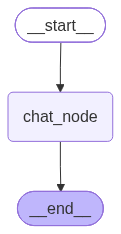

In [228]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())